# 02 — Aprofundamento das Decisões Pendentes

## Princípio orientador

> **Este notebook estabelece uma base de investigação sem remover registros e sem converter
> anomalias em erros por suposição. Os resultados devem orientar a preparação da base auditada.**

Este notebook aprofunda os pontos que ainda não possuem evidência suficiente para uma decisão
definitiva. Cada seção apresenta dados, gráficos, interpretação permitida e condição necessária
para aprovação.

Nenhuma transformação destrutiva é executada.

In [1]:
from pathlib import Path
import re
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")
AP_PATH = str(BASE / "datasets" / "apontamentos" / "desenvolver_apontamentos.parquet")
RULES_PATH = BASE / "Alarmes - Regra de Negocio.xlsx"

con = duckdb.connect()
con.execute("SET threads=4")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")
con.execute(f"CREATE OR REPLACE VIEW ap AS SELECT * FROM read_parquet('{AP_PATH}')")

def query(sql):
    return con.sql(sql).df()

print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: /home/f_szekut/projects/vale_correct


## 1. Conflitos entre ID e nome do alarme

Um `Id_Alarme` associado a nomes diferentes pode resultar de:

- espaços externos;
- variação de capitalização ou sufixo;
- problema de codificação de caracteres;
- mudança legítima de nomenclatura;
- reutilização indevida do identificador.

Primeiro medimos o efeito de normalizações progressivas. Normalizar não significa substituir
automaticamente: a análise serve para separar conflitos puramente textuais de conflitos semânticos.

,criterio,ids_conflitantes
0,Nome bruto,122
1,Após trim,120
2,Unicode/capitalização/espaços,120
3,Também sem sufixo L-1850,11


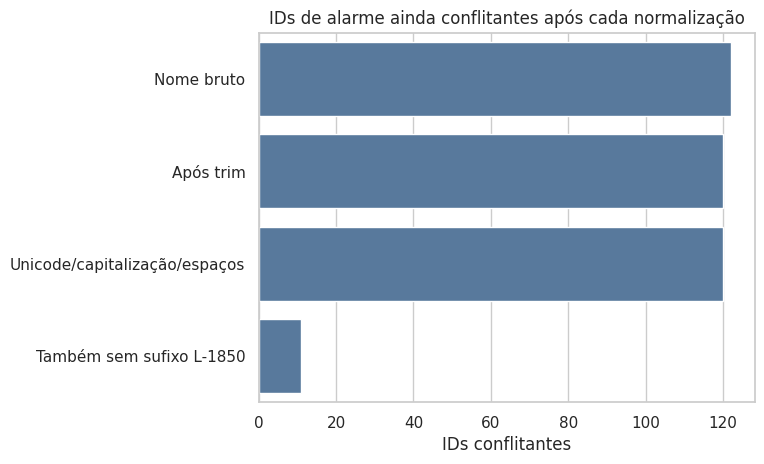

In [2]:
alarm_names = query(
    '''
    SELECT Id_Alarme, Alarme, count(*) AS registros,
           min(Data_Evento) AS inicio, max(Data_Evento) AS fim
    FROM tel GROUP BY 1, 2
    '''
)

def normalize_text(value, remove_suffix=False):
    value = str(value).strip().casefold()
    value = unicodedata.normalize("NFKD", value)
    value = "".join(ch for ch in value if not unicodedata.combining(ch))
    value = re.sub(r"\s+", " ", value)
    if remove_suffix:
        value = re.sub(r"\s*\(l-1850\)$", "", value)
    return value

alarm_names["nome_trim"] = alarm_names["Alarme"].str.strip()
alarm_names["nome_normalizado"] = alarm_names["Alarme"].map(normalize_text)
alarm_names["nome_sem_sufixo_modelo"] = alarm_names["Alarme"].map(
    lambda value: normalize_text(value, remove_suffix=True)
)

conflict_summary = pd.DataFrame([
    {"criterio": "Nome bruto", "ids_conflitantes": (alarm_names.groupby("Id_Alarme")["Alarme"].nunique() > 1).sum()},
    {"criterio": "Após trim", "ids_conflitantes": (alarm_names.groupby("Id_Alarme")["nome_trim"].nunique() > 1).sum()},
    {"criterio": "Unicode/capitalização/espaços", "ids_conflitantes": (alarm_names.groupby("Id_Alarme")["nome_normalizado"].nunique() > 1).sum()},
    {"criterio": "Também sem sufixo L-1850", "ids_conflitantes": (alarm_names.groupby("Id_Alarme")["nome_sem_sufixo_modelo"].nunique() > 1).sum()},
])
display(conflict_summary)

ax = sns.barplot(data=conflict_summary, x="ids_conflitantes", y="criterio", color="#4C78A8")
ax.set(title="IDs de alarme ainda conflitantes após cada normalização", xlabel="IDs conflitantes", ylabel="")
plt.show()

In [3]:
remaining_conflicts = (
    alarm_names.groupby("Id_Alarme")
    .filter(lambda group: group["nome_sem_sufixo_modelo"].nunique() > 1)
    .sort_values(["Id_Alarme", "registros"], ascending=[True, False])
)
display(remaining_conflicts.head(80))

print(
    "Decisão pendente: normalizações textuais podem compor uma coluna derivada, "
    "mas conflitos restantes não devem ser consolidados sem catálogo mestre."
)

,Id_Alarme,Alarme,registros,inicio,fim,nome_trim,nome_normalizado,nome_sem_sufixo_modelo
817,16830976,MC - QUEDA NA PRESSÃO ÓLEO MOTOR <270KPA,7053,2025-01-01 02:14:41.000,2025-05-17 06:38:54.460,MC - QUEDA NA PRESSÃO ÓLEO MOTOR <270KPA,mc - queda na pressao oleo motor <270kpa,mc - queda na pressao oleo motor <270kpa
1238,16830976,MC - QUEDA NA PRESS??O ÓLEO MOTOR <270KPA,2,2025-01-06 07:18:41.000,2025-01-12 16:26:09.000,MC - QUEDA NA PRESS??O ÓLEO MOTOR <270KPA,mc - queda na press??o oleo motor <270kpa,mc - queda na press??o oleo motor <270kpa
320,16830976,MC - QUEDA NA PRESSÃO ??LEO MOTOR <270KPA,1,2025-01-07 12:02:27.000,2025-01-07 12:02:27.000,MC - QUEDA NA PRESSÃO ??LEO MOTOR <270KPA,mc - queda na pressao ??leo motor <270kpa,mc - queda na pressao ??leo motor <270kpa
1032,16831802,MC - QUEDA PRESSÃO DO ÓLEO MOTOR,461,2025-01-01 00:24:02.000,2025-01-31 11:13:45.903,MC - QUEDA PRESSÃO DO ÓLEO MOTOR,mc - queda pressao do oleo motor,mc - queda pressao do oleo motor
308,16831802,MC - QUEDA PRESSÃO DO ??LEO MOTOR,1,2025-01-08 18:22:32.000,2025-01-08 18:22:32.000,MC - QUEDA PRESSÃO DO ??LEO MOTOR,mc - queda pressao do ??leo motor,mc - queda pressao do ??leo motor
471,16832115,MC - TEMPERATURA DA DIREÇÃO >95C,24004,2025-01-01 00:41:56.000,2025-05-19 21:05:30.417,MC - TEMPERATURA DA DIREÇÃO >95C,mc - temperatura da direcao >95c,mc - temperatura da direcao >95c
628,16832115,MC - TEMPERATURA DA DIREÇ??O >95C,2,2025-01-02 14:59:57.000,2025-01-16 19:37:53.000,MC - TEMPERATURA DA DIREÇ??O >95C,mc - temperatura da direc??o >95c,mc - temperatura da direc??o >95c
113,16833710,TESTE-OP ENTRADA ARTICULADA,3806,2025-01-30 17:14:05.460,2025-06-30 23:31:31.413,TESTE-OP ENTRADA ARTICULADA,teste-op entrada articulada,teste-op entrada articulada
1360,16833710,TESTE-OP ENTRADA OPERAÇÃO ARTICULADA.,1,2025-01-30 15:40:08.693,2025-01-30 15:40:08.693,TESTE-OP ENTRADA OPERAÇÃO ARTICULADA.,teste-op entrada operacao articulada.,teste-op entrada operacao articulada.
101,16833711,TESTE-OP ENTRADA ARTICULADA,7491,2025-01-30 15:54:39.383,2025-06-26 23:09:00.240,TESTE-OP ENTRADA ARTICULADA,teste-op entrada articulada,teste-op entrada articulada


Decisão pendente: normalizações textuais podem compor uma coluna derivada, mas conflitos restantes não devem ser consolidados sem catálogo mestre.


In [4]:
conflict_table = (
    remaining_conflicts.groupby("Id_Alarme")
    .agg(
        nomes=("nome_sem_sufixo_modelo", "nunique"),
        variantes=("Alarme", lambda s: list(dict.fromkeys(s.tolist()))),
        registros=("registros", "sum"),
    )
    .reset_index()
    .sort_values(["nomes", "registros"], ascending=[False, False])
)
display(conflict_table)

print(
    "Leitura prática: os 11 casos remanescentes representam 11 Id_Alarme com mais de uma "
    "descrição normalizada. Dois grupos são variações por caractere/encoding e nove pertencem "
    "à família TESTE-OP ENTRADA ARTICULADA, que podem ser consolidados em uma descrição oficial "
    "sem afetar o treinamento se a chave operacional permanecer o Id_Alarme."
)

,Id_Alarme,nomes,variantes,registros
0,16830976,3,"[MC - QUEDA NA PRESSÃO ÓLEO MOTOR <270KPA, MC ...",7056
9,16833716,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA...",26041
2,16832115,2,"[MC - TEMPERATURA DA DIREÇÃO >95C, MC - TEMPER...",24006
8,16833715,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA...",19155
7,16833714,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA...",16752
5,16833712,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA...",7813
4,16833711,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA...",7492
10,16833717,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA...",5342
3,16833710,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA...",3807
6,16833713,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA...",2359


Leitura prática: os 11 casos remanescentes representam 11 Id_Alarme com mais de uma descrição normalizada. Dois grupos são variações por caractere/encoding e nove pertencem à família TESTE-OP ENTRADA ARTICULADA, que podem ser consolidados em uma descrição oficial sem afetar o treinamento se a chave operacional permanecer o Id_Alarme.


## 2. Repetições lógicas que não são cópias exatas

A maior parte das repetições lógicas é cópia exata em todas as colunas, exceto ID. Restam poucos
casos em que timestamp, TAG, alarme, valor, classe e target coincidem, mas algum campo contextual
difere.

Esses casos são apresentados individualmente porque uma regra automática ampla seria desproporcional.

In [5]:
logical_nonexact = query(
    '''
    WITH logical_groups AS (
      SELECT Data_Evento, TAG, Id_Alarme, Valor, Classe, Is_Dont_Go, count(*) AS repeticoes
      FROM tel GROUP BY ALL HAVING count(*) > 1
    )
    SELECT t.Data_Evento, t.TAG, t.Id_Alarme, t.Alarme, t.Valor, t.Classe, t.Is_Dont_Go,
           count(*) AS linhas,
           count(DISTINCT (t.Inicio_Turno, t.Fim_Turno, t.Nome_Operador_Anon,
                           t.Matricula_Operador_Hash, t.Id_Criticidade, t.Criticidade)) AS variantes_contextuais,
           list(DISTINCT t.Inicio_Turno ORDER BY t.Inicio_Turno) AS turnos,
           list(DISTINCT t.Nome_Operador_Anon ORDER BY t.Nome_Operador_Anon) AS operadores
    FROM tel t
    JOIN logical_groups g USING (Data_Evento, TAG, Id_Alarme, Valor, Classe, Is_Dont_Go)
    GROUP BY 1, 2, 3, 4, 5, 6, 7
    HAVING variantes_contextuais > 1
    ORDER BY variantes_contextuais DESC, Data_Evento
    '''
)
display(logical_nonexact)

logical_nonexact["em_fronteira_turno"] = logical_nonexact["Data_Evento"].dt.hour.isin([6, 18])
display(logical_nonexact["em_fronteira_turno"].value_counts().rename_axis("fronteira_turno").reset_index(name="grupos"))

print(
    "Leitura prática: estas linhas não são cópias exatas; são o mesmo alarme para o mesmo "
    "equipamento em outro momento, às vezes na troca de turno ou com operador diferente. "
    "Como são raras e não representam Don't Go, a decisão conservadora é preservá-las sem alterações."
)

,Data_Evento,TAG,Id_Alarme,Alarme,Valor,Classe,Is_Dont_Go,linhas,variantes_contextuais,turnos,operadores
0,2025-01-06 06:00:00.000,CA65930,335609862,1st Tire Tag Timeout,0,NULL,0,4,4,"[2025-01-05 18:00:00.000, 2025-01-06 06:00:00....","[OP_141, OP_275]"
1,2025-03-01 18:00:00.000,PE3798,1241579532,Engine \/ Retarder Torque Mode - Not Defined\/...,0,NULL,0,4,4,"[2025-03-01 06:00:00.000, 2025-03-01 18:00:00....","[OP_298, OP_376]"
2,2025-04-29 06:00:00.000,PE3799,1074008257,Dump Wheel Limited By End Of Travel (L-1850),0,NULL,0,4,4,"[2025-04-28 18:00:00.000, 2025-04-29 06:00:00....","[OP_042, OP_283]"
3,2025-01-12 23:08:37.390,CA65934,84607011,Torque Converter Screen - Active,2,Activate,0,2,2,[2025-01-12 18:00:00.000],[OP_135]


,fronteira_turno,grupos
0,True,3
1,False,1


Leitura prática: estas linhas não são cópias exatas; são o mesmo alarme para o mesmo equipamento em outro momento, às vezes na troca de turno ou com operador diferente. Como são raras e não representam Don't Go, a decisão conservadora é preservá-las sem alterações.


## 3. Perfil das anomalias de volume

O objetivo é identificar se os candidatos formam um único tipo de problema ou vários fenômenos.
Para cada TAG/dia marcado pelo critério `mediana + 10 × MAD`, medimos:

- razão entre volume observado e mediana da TAG;
- concentração do alarme dominante;
- proporção de timestamps distintos;
- presença de linhas `Is_Dont_Go`;
- diversidade de alarmes.

Alta concentração em um único sinal sugere investigação localizada. Baixa concentração pode indicar
atividade geral elevada ou múltiplos fenômenos simultâneos.

In [6]:
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE tag_day AS
    SELECT TAG, cast(Data_Evento AS DATE) AS data,
           count(*) AS registros,
           count(DISTINCT Data_Evento) AS timestamps_distintos,
           count(DISTINCT Alarme) AS alarmes_distintos,
           sum(Is_Dont_Go) AS linhas_dont_go
    FROM tel GROUP BY 1, 2
    '''
)
volume_candidates = query(
    '''
    WITH med AS (
      SELECT TAG, median(registros) AS mediana FROM tag_day GROUP BY TAG
    ), stats AS (
      SELECT d.TAG, m.mediana,
             median(abs(d.registros - m.mediana)) AS mad
      FROM tag_day d JOIN med m USING (TAG)
      GROUP BY d.TAG, m.mediana
    ), flagged AS (
      SELECT d.*, s.mediana, s.mad,
             d.registros / s.mediana AS razao_mediana
      FROM tag_day d JOIN stats s USING (TAG)
      WHERE d.registros > s.mediana + 10 * greatest(s.mad, 1)
    ), alarm_counts AS (
      SELECT t.TAG, cast(t.Data_Evento AS DATE) AS data, trim(t.Alarme) AS alarme,
             count(*) AS registros_alarme
      FROM tel t JOIN flagged f
        ON t.TAG = f.TAG AND cast(t.Data_Evento AS DATE) = f.data
      GROUP BY 1, 2, 3
    ), ranked AS (
      SELECT *, row_number() OVER (PARTITION BY TAG, data ORDER BY registros_alarme DESC) AS ordem
      FROM alarm_counts
    )
    SELECT f.*, r.alarme AS alarme_dominante, r.registros_alarme,
           r.registros_alarme / f.registros AS concentracao_dominante,
           f.timestamps_distintos / f.registros AS proporcao_timestamps_distintos
    FROM flagged f JOIN ranked r USING (TAG, data)
    WHERE r.ordem = 1
    ORDER BY razao_mediana DESC
    '''
)
display(volume_candidates.head(30))

,TAG,data,registros,timestamps_distintos,alarmes_distintos,linhas_dont_go,mediana,mad,razao_mediana,alarme_dominante,registros_alarme,concentracao_dominante,proporcao_timestamps_distintos
0,PE3798,2025-06-29,1334065,1317842,39,0.0,41714.0,8429.0,31.981229,Remote PTO Preprogrammed Speed Control Switch ...,645199,0.483634,0.987839
1,CA65927,2025-02-22,5839,5839,33,260.0,357.5,125.0,16.332867,Engine Coolant Level - Inactive,2360,0.404179,1.000000
2,CA65932,2025-03-26,12356,12356,15,0.0,787.0,461.0,15.700127,Final Drive Bypass Solenoid - Inactive,6041,0.488912,1.000000
3,CA65908,2025-01-13,4377,2630,23,241.0,282.0,83.0,15.521277,Engine Coolant Level - Active,1940,0.443226,0.600868
4,CA65931,2025-03-09,8508,7137,41,406.0,567.5,265.5,14.992070,Engine Coolant Level - Inactive,3768,0.442877,0.838858
5,CA65932,2025-04-21,9654,9653,16,0.0,787.0,461.0,12.266836,Final Drive Bypass Solenoid - Active,4646,0.481251,0.999896
6,CA65932,2025-03-25,9201,9201,17,0.0,787.0,461.0,11.691233,Final Drive Bypass Solenoid - Active,4482,0.487121,1.000000
7,CA65927,2025-02-21,4090,4090,29,166.0,357.5,125.0,11.440559,Engine Coolant Level - Active,1651,0.403667,1.000000
8,CA65931,2025-03-06,5984,4911,32,213.0,567.5,265.5,10.544493,Engine Coolant Level - Active,2120,0.354278,0.820689
9,CA65932,2025-03-30,8243,8243,23,0.0,787.0,461.0,10.473952,Final Drive Bypass Solenoid - Active,3940,0.477981,1.000000


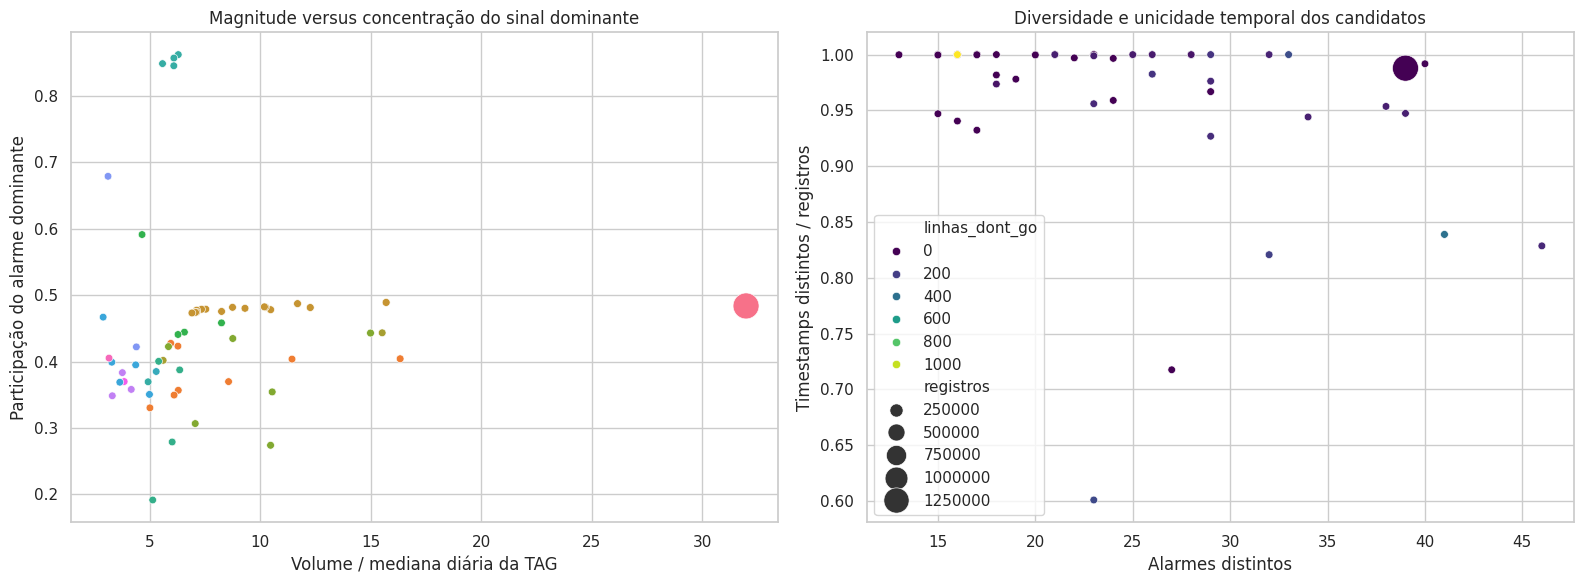

,perfil,candidatos
0,moderadamente concentrado,51
1,altamente concentrado,4
2,concentrado,2
3,distribuído,1


Leitura do gráfico 1: pontos no canto superior direito são candidatos com volume muito acima da própria mediana e forte concentração em um único alarme. Isso sugere um fenômeno localizado, não um aumento geral de atividade.
Leitura do gráfico 2: quanto maior a proporção de timestamps distintos, mais o volume se parece com uma sequência contínua de eventos reais; quanto menor essa proporção, maior a chance de repetição mecânica do mesmo estado. O eixo de alarmes distintos ajuda a separar um pico monotemático de um pico espalhado por vários alarmes.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=volume_candidates, x="razao_mediana", y="concentracao_dominante",
    hue="TAG", size="registros", sizes=(30, 350), ax=axes[0], legend=False
)
axes[0].set(
    title="Magnitude versus concentração do sinal dominante",
    xlabel="Volume / mediana diária da TAG",
    ylabel="Participação do alarme dominante",
)

sns.scatterplot(
    data=volume_candidates, x="alarmes_distintos", y="proporcao_timestamps_distintos",
    hue="linhas_dont_go", palette="viridis", size="registros", sizes=(30, 350), ax=axes[1]
)
axes[1].set(
    title="Diversidade e unicidade temporal dos candidatos",
    xlabel="Alarmes distintos",
    ylabel="Timestamps distintos / registros",
)
plt.tight_layout()
plt.show()

candidate_classes = pd.cut(
    volume_candidates["concentracao_dominante"],
    bins=[-0.01, 0.25, 0.50, 0.80, 1.0],
    labels=["distribuído", "moderadamente concentrado", "concentrado", "altamente concentrado"],
)
display(candidate_classes.value_counts().rename_axis("perfil").reset_index(name="candidatos"))

print(
    "Leitura do gráfico 1: pontos no canto superior direito são candidatos com volume muito acima "
    "da própria mediana e forte concentração em um único alarme. Isso sugere um fenômeno localizado, "
    "não um aumento geral de atividade."
)
print(
    "Leitura do gráfico 2: quanto maior a proporção de timestamps distintos, mais o volume se parece "
    "com uma sequência contínua de eventos reais; quanto menor essa proporção, maior a chance de "
    "repetição mecânica do mesmo estado. O eixo de alarmes distintos ajuda a separar um pico "
    "monotemático de um pico espalhado por vários alarmes."
)

## 4. Sobreposições dos apontamentos da CA65789

As sobreposições estão concentradas em uma única TAG. Investigamos pares de classe, duração e
distribuição temporal.

Sobreposições entre `Hibernando` e outros estados podem indicar uma regra de registro paralela, e não
necessariamente linhas incorretas. Sem compreender essa semântica, escolher arbitrariamente uma classe
apagaria informação.

,Tag,Inicio,Fim,Classe,classe_anterior,fim_anterior,sobreposicao_s
0,CA65789,2025-01-06 18:00:00,2025-01-06 19:00:00,Hibernando,Parado,2025-01-06 18:06:51,411
1,CA65789,2025-01-06 18:06:51,2025-01-06 19:00:00,Operando,Hibernando,2025-01-06 19:00:00,3189
2,CA65789,2025-01-06 19:00:00,2025-01-06 20:00:00,Hibernando,Operando,2025-01-06 20:00:00,3600
3,CA65789,2025-01-06 20:00:00,2025-01-06 21:00:00,Hibernando,Operando,2025-01-06 20:18:59,1139
4,CA65789,2025-01-06 20:18:59,2025-01-06 20:22:13,Parado,Hibernando,2025-01-06 21:00:00,2461
5,CA65789,2025-01-06 21:00:00,2025-01-06 22:00:00,Hibernando,Operando,2025-01-06 21:23:12,1392
6,CA65789,2025-01-06 21:23:12,2025-01-06 22:00:00,Parado,Hibernando,2025-01-06 22:00:00,2208
7,CA65789,2025-01-06 22:00:00,2025-01-06 23:00:00,Hibernando,Parado,2025-01-06 23:00:00,3600
8,CA65789,2025-01-06 23:00:00,2025-01-07 00:00:00,Hibernando,Parado,2025-01-06 23:43:43,2623
9,CA65789,2025-01-06 23:43:43,2025-01-07 00:00:00,Parado,Hibernando,2025-01-07 00:00:00,977


,classe_anterior,Classe,casos,mediana_s,max_s
4,Operando,Hibernando,174,2645.0,3600
2,Hibernando,Parado,93,2340.0,3519
1,Hibernando,Operando,67,2836.0,3591
5,Parado,Hibernando,62,793.5,3600
3,Manutenção,Hibernando,28,3600.0,3600
0,Hibernando,Manutenção,3,2286.0,3213


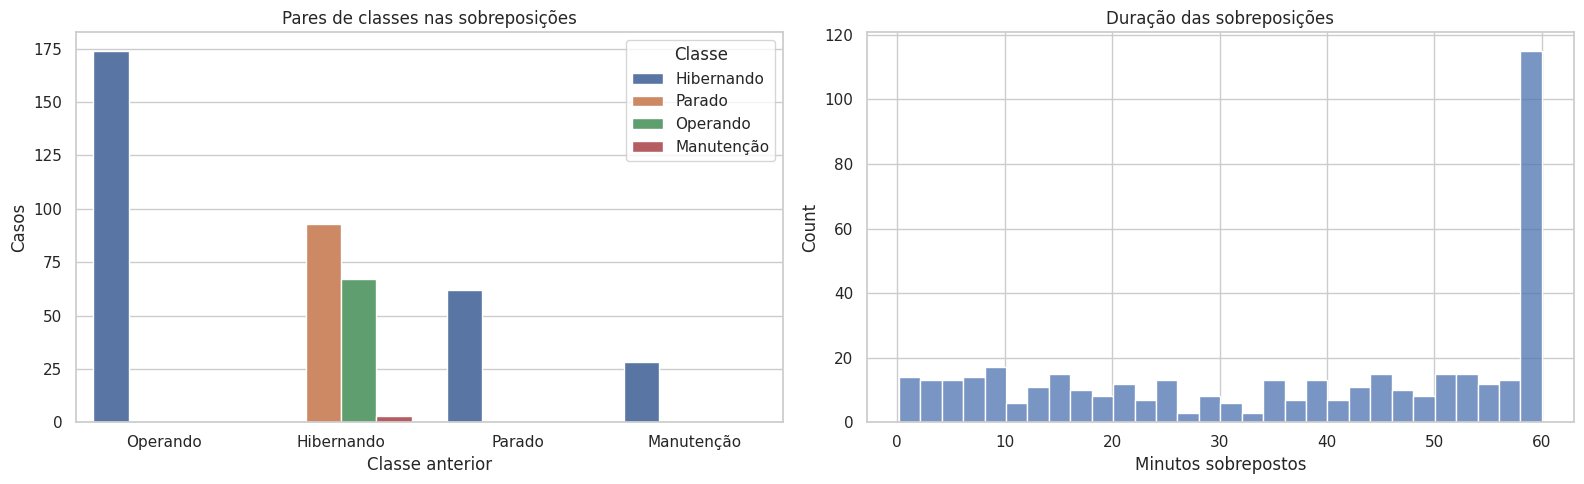

Decisão pendente: confirmar se Hibernando é um estado paralelo antes de resolver sobreposições.


In [8]:
overlaps = query(
    '''
    WITH ordered AS (
      SELECT *,
             lag(Fim) OVER (PARTITION BY Tag ORDER BY Inicio, Fim, Id) AS fim_anterior,
             lag(Classe) OVER (PARTITION BY Tag ORDER BY Inicio, Fim, Id) AS classe_anterior
      FROM ap
    )
    SELECT Tag, Inicio, Fim, Classe, classe_anterior, fim_anterior,
           date_diff('second', Inicio, fim_anterior) AS sobreposicao_s
    FROM ordered
    WHERE Inicio < fim_anterior
    ORDER BY Inicio
    '''
)
display(overlaps.head(30))

overlap_pairs = (
    overlaps.groupby(["classe_anterior", "Classe"])
    .agg(casos=("sobreposicao_s", "size"), mediana_s=("sobreposicao_s", "median"), max_s=("sobreposicao_s", "max"))
    .reset_index()
    .sort_values("casos", ascending=False)
)
display(overlap_pairs)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=overlap_pairs, y="casos", x="classe_anterior", hue="Classe", ax=axes[0])
axes[0].set(title="Pares de classes nas sobreposições", xlabel="Classe anterior", ylabel="Casos")
sns.histplot(overlaps["sobreposicao_s"] / 60, bins=30, ax=axes[1])
axes[1].set(title="Duração das sobreposições", xlabel="Minutos sobrepostos")
plt.tight_layout()
plt.show()

print("Decisão pendente: confirmar se Hibernando é um estado paralelo antes de resolver sobreposições.")

## 5. Sensibilidade da definição de episódios

Uma linha positiva não equivale necessariamente a um episódio independente. Para visualizar a
sensibilidade, calculamos o número de episódios para diversos intervalos mínimos entre ocorrências
consecutivas da mesma TAG e alarme.

O gráfico ajuda a identificar regiões de estabilidade, mas a escolha final exige justificativa
operacional.

,intervalo,segundos,episodios,reducao_vs_linhas_pct
0,1 min,60,15561,22.046889
1,5 min,300,9755,51.132151
2,15 min,900,7312,63.370404
3,30 min,1800,5890,70.493938
4,1 h,3600,4428,77.817854
5,2 h,7200,3500,82.466687
6,4 h,14400,2794,86.003406
7,8 h,28800,2317,88.392947
8,24 h,86400,1685,91.558962


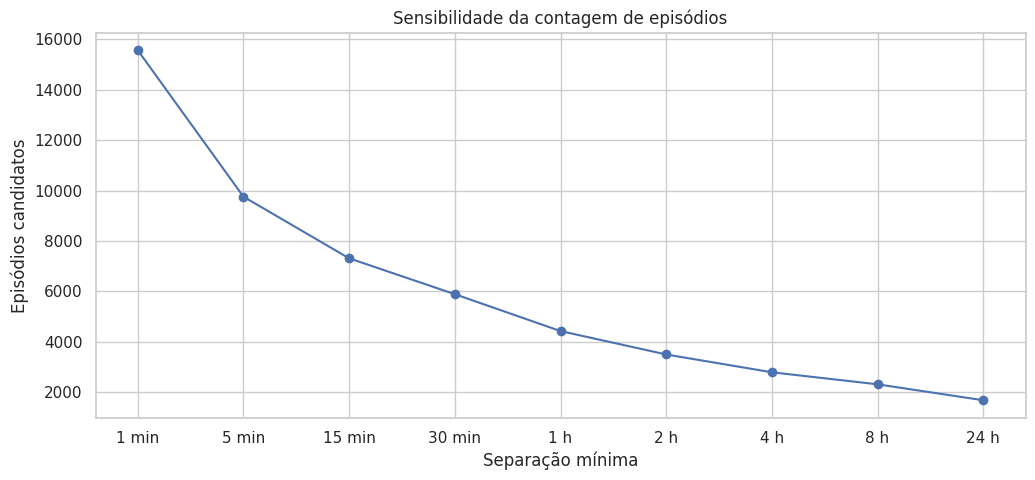

Decisão pendente: intervalo de episódio depende de validação operacional e das regras do catálogo.


In [9]:
positive_gaps = query(
    '''
    SELECT date_diff(
             'second',
             lag(Data_Evento) OVER (PARTITION BY TAG, Alarme ORDER BY Data_Evento),
             Data_Evento
           ) AS gap_s
    FROM tel WHERE Is_Dont_Go = 1
    '''
)
thresholds = [
    ("1 min", 60), ("5 min", 300), ("15 min", 900), ("30 min", 1800),
    ("1 h", 3600), ("2 h", 7200), ("4 h", 14400), ("8 h", 28800), ("24 h", 86400),
]
episode_curve = pd.DataFrame([
    {"intervalo": label, "segundos": seconds, "episodios": int(positive_gaps["gap_s"].isna().sum() + (positive_gaps["gap_s"] > seconds).sum())}
    for label, seconds in thresholds
])
episode_curve["reducao_vs_linhas_pct"] = (1 - episode_curve["episodios"] / len(positive_gaps)) * 100
display(episode_curve)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(episode_curve["intervalo"], episode_curve["episodios"], marker="o")
ax.set(title="Sensibilidade da contagem de episódios", xlabel="Separação mínima", ylabel="Episódios candidatos")
plt.show()

print("Decisão pendente: intervalo de episódio depende de validação operacional e das regras do catálogo.")

## 6. Aplicabilidade das regras de negócio

O catálogo mistura regras simples e regras temporais. Padronizamos `NIVEL` apenas para análise textual
e mostramos a distribuição de `SITUACAO`, `QTD` e `TEMPO`.

Regras com `QTD = 1` e `TEMPO = 0` são candidatas a aplicação direta, mas ainda dependem da
interpretação de `SITUACAO` e `NIVEL`. Regras consecutivas exigem definição explícita de sequência.

,situacao,regras
0,Em qualquer situação,81
1,Mediante alarme nível 3,16
2,Após cinco alarmes consecutivos,11
3,Mediante cinco alarmes nivel 2 consecutivos.,6
4,Mediante cinco alarmes consecutivos.,5
5,Mediante dois alarmes de tendência,5
6,Mediante dez alarmes nivel 2 consecutivos.,3
7,Mediante três alarmes,3
8,Após três alarmes nível 2,3
9,"Mediante dez alarmes nível 2 consecutivos,",3


,QTD,TEMPO,regras
0,1,0,89
5,5,720,24
1,2,360,15
4,5,360,7
2,3,360,6
3,3,720,4
6,10,360,3
7,10,720,3


,NIVEL,NIVEL_NORMALIZADO,regras
0,Alto,alto,69
1,Muito Alto,muito alto,76
2,Muito alto,muito alto,6


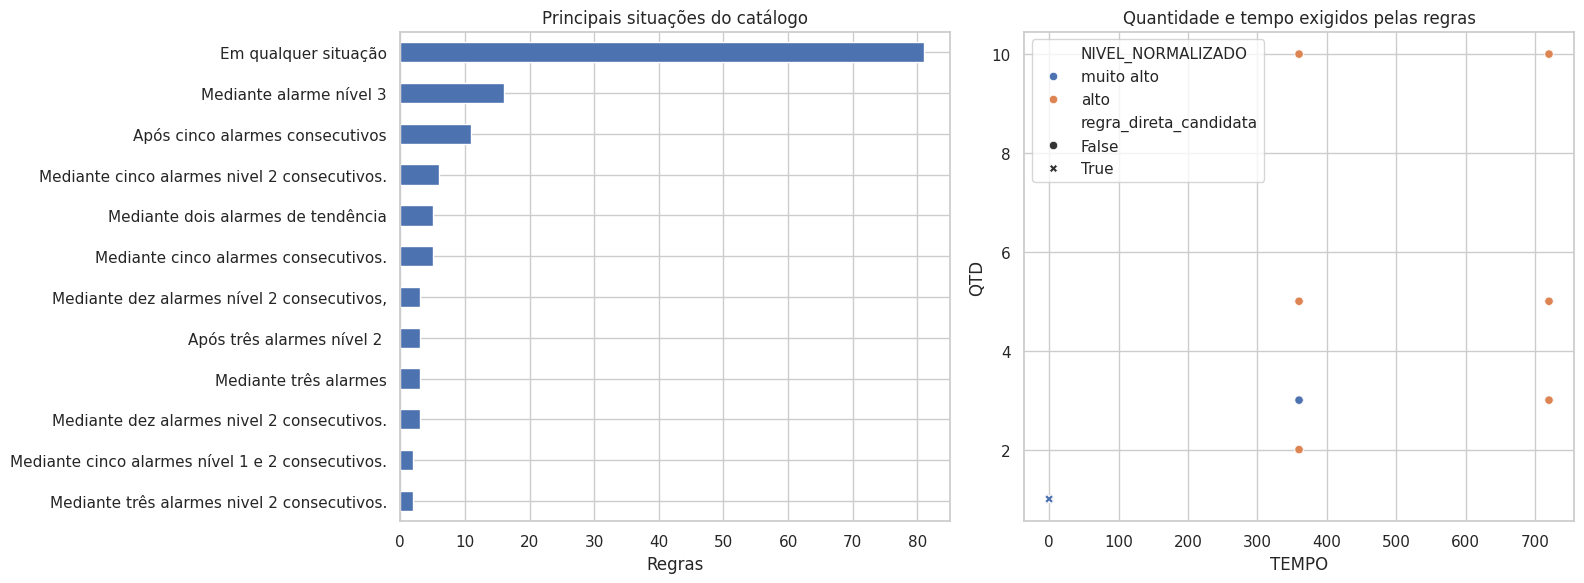

,TIPO,EVENTO,SITUACAO,QTD,TEMPO,NIVEL,NIVEL_NORMALIZADO,regra_direta_candidata
3,ALARME OEM,Engine Coolant Level - Active,Mediante alarme nível 3,1,0,Muito Alto,muito alto,True
5,ALARME OEM,Low Engine Coolant Level,Mediante alarme nível 3,1,0,Muito Alto,muito alto,True
7,ALARME OEM,Low Coolant Level,Em qualquer situação,1,0,Alto,alto,True
8,ALARME OEM,Engine Coolant Level Low,Mediante alarme nível 3,1,0,Muito Alto,muito alto,True
9,ALARME OEM,Engine Coolant Level Low,Em qualquer situação,1,0,Alto,alto,True
10,ALARME OEM,Aftercooler Level - Active,Mediante alarme nível 3,1,0,Alto,alto,True
13,ALARME OEM,Coolant Level - Data Erratic - Ce (Active),Em qualquer situação,1,0,Muito alto,muito alto,True
14,ALARME OEM,Coolant Level - Valid But Low - Most Severe - ...,Em qualquer situação,1,0,Muito alto,muito alto,True
15,ALARME OEM,Coolant Level - Valid But Low - Most Severe - ...,Em qualquer situação,1,0,Muito Alto,muito alto,True
18,ALARME OEM,Very Low Hydraulic Oil Level,Em qualquer situação,1,0,Muito Alto,muito alto,True


Regras candidatas a aplicação direta: 89 de 151


In [10]:
rules = pd.read_excel(RULES_PATH, sheet_name="CMA")
rules["NIVEL_NORMALIZADO"] = rules["NIVEL"].astype(str).str.strip().str.casefold()
rules["regra_direta_candidata"] = (rules["QTD"] == 1) & (rules["TEMPO"] == 0)

display(rules["SITUACAO"].value_counts().rename_axis("situacao").reset_index(name="regras"))
display(rules.groupby(["QTD", "TEMPO"]).size().reset_index(name="regras").sort_values("regras", ascending=False))
display(rules.groupby(["NIVEL", "NIVEL_NORMALIZADO"]).size().reset_index(name="regras"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
rules["SITUACAO"].value_counts().head(12).sort_values().plot.barh(ax=axes[0])
axes[0].set(title="Principais situações do catálogo", xlabel="Regras", ylabel="")
sns.scatterplot(data=rules, x="TEMPO", y="QTD", hue="NIVEL_NORMALIZADO", style="regra_direta_candidata", ax=axes[1])
axes[1].set(title="Quantidade e tempo exigidos pelas regras")
plt.tight_layout()
plt.show()

display(rules[rules["regra_direta_candidata"]].head(30))
print(f"Regras candidatas a aplicação direta: {rules['regra_direta_candidata'].sum()} de {len(rules)}")

## 7. Matriz atual de decisão

| Tema | Evidência atual | Decisão possível agora | Pendência |
|---|---|---|---|
| Espaços externos em alarmes | Diferença puramente textual | Criar coluna normalizada com `trim` | Preservar bruto |
| Conflitos ID/nome | Parte explicada por texto; parte semântica | Não consolidar conflitos restantes | Catálogo mestre |
| Duplicatas exatas | Iguais em todas as colunas exceto ID | Deduplicar na camada analítica | Guardar mapa de IDs |
| Repetições não exatas | Poucos casos, associados a contexto | Preservar | Regra de fronteira de turno |
| PE3798 29/06 | Alternância Remote PTO em milissegundos | Marcar sinais/intervalo, não remover dia | Validação operacional |
| Outros volumes anômalos | Perfis heterogêneos | Manter flags | Drill-down por perfil |
| Sobreposições CA65789 | Hibernando domina os pares | Preservar estados | Confirmar semântica |
| Episódios | Contagem altamente sensível ao intervalo | Não fixar intervalo ainda | Validação operacional |
| Regras CMA | Regras diretas e temporais misturadas | Implementar somente após formalização | Interpretar situações |

O próximo passo técnico recomendado é construir uma camada auditada **sem exclusões irreversíveis**,
contendo colunas normalizadas, flags e tabelas de rastreabilidade.